<a href="https://colab.research.google.com/github/Reben80/Data201/blob/main/DATA_201_Week_11a_Regression_with_Ensemble_Methods_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author:  Prof. L. A. Perine, Montgomery College.

#Ensemble Methods (Bagging and Boosting)

In this lecture demo, we explore the modeling methodologies for **ensemble learning**. **Random Forest** and **Gradient Boosting** are specific, highly effective implementations of the two main ensemble methodologies: **Bagging** and **Boosting**, respectively. The **Decision Tree** is the fundamental base learner used by both.


##1. Decision Tree (Base Model)

The Decision Tree Regressor is the single base model upon which both Bagging and Boosting are built.

**Role**: A single decision tree is powerful but highly susceptible to overfitting (high variance), meaning it fits the training data too closely and performs poorly on unseen data.

**Method:** It partitions the feature space into distinct regions and predicts the average (or majority) target value for any sample falling into that region.

This is a qualitative visual comparison of a single decision tree vs. tree ensembles.  Source:  https://towardsdatascience.com/10-decision-trees-are-better-than-1-719406680564/

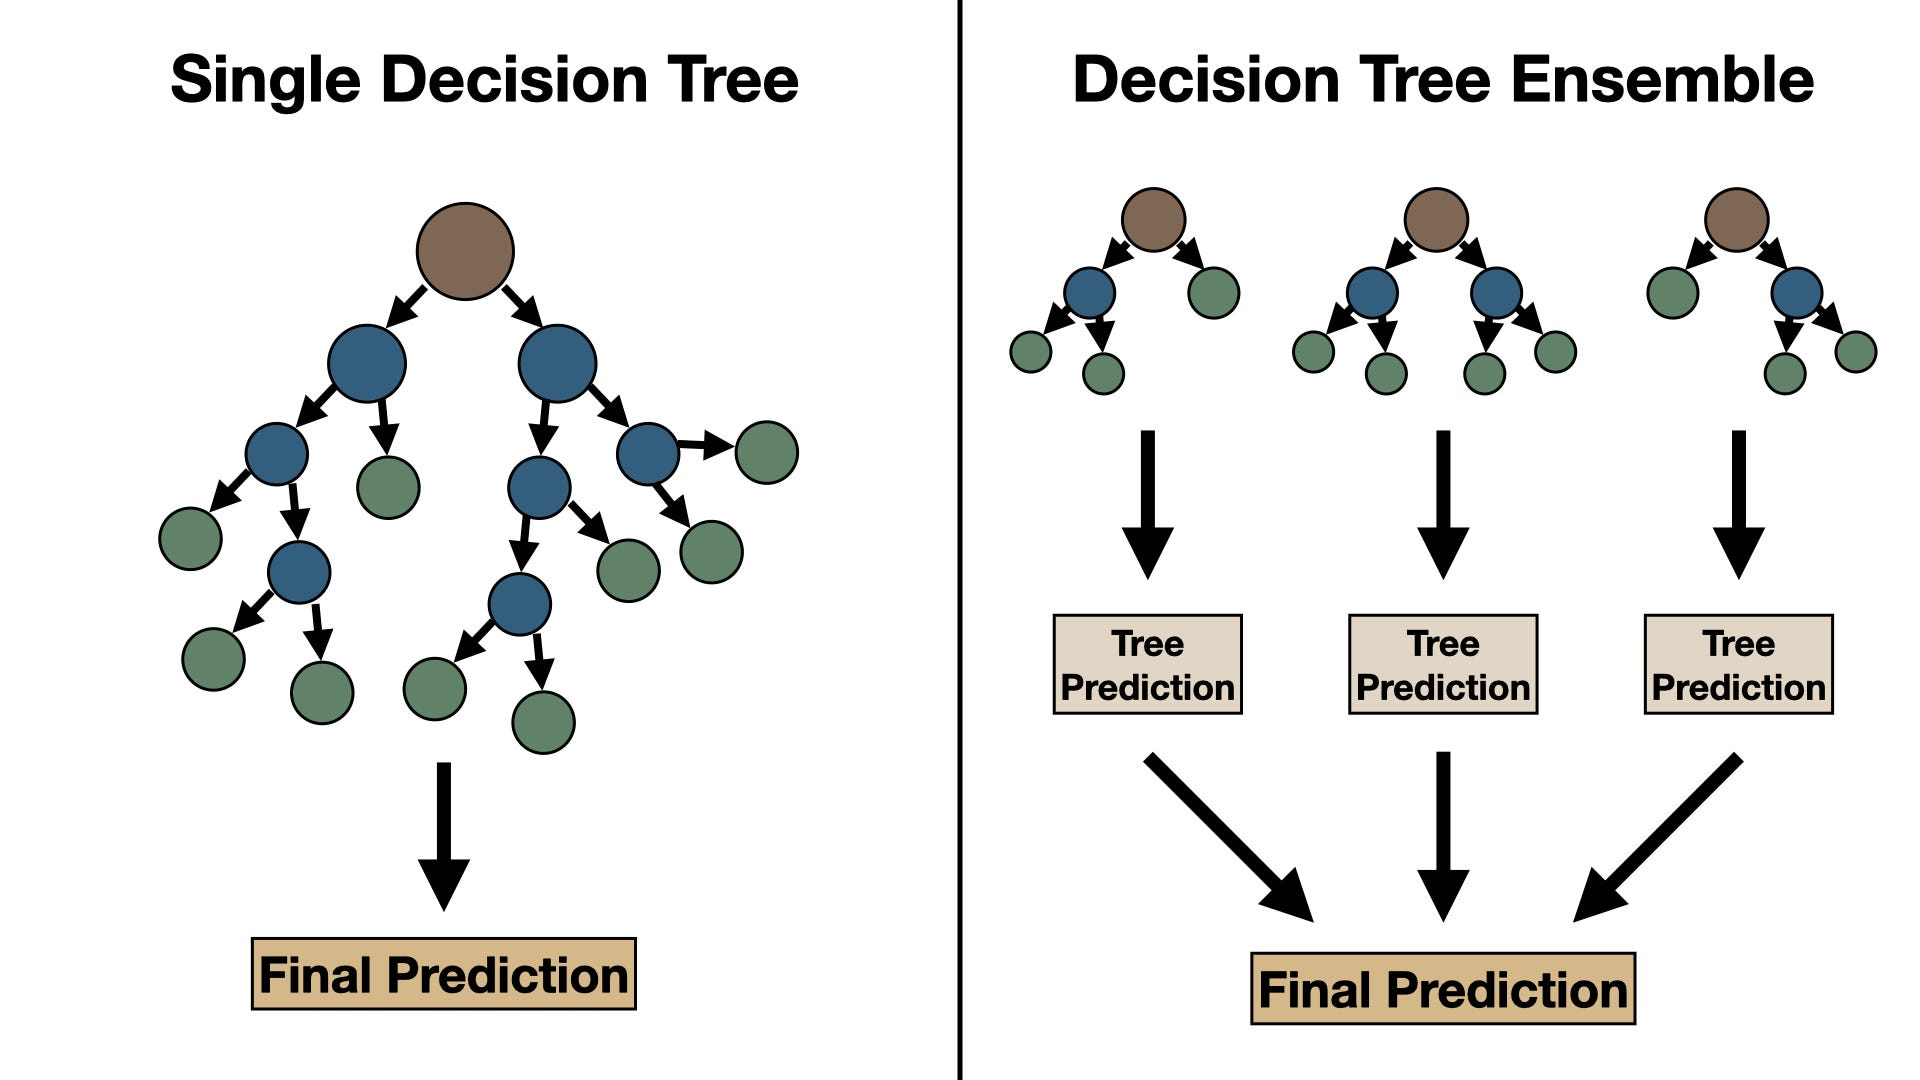

##2. Random Forest (Bagging)

The Random Forest Regressor is the canonical example of a Bagging ensemble method.

**Bagging** stands for **B**ootstrap **Agg**regating.

**How it Works:**

**Bootstrap:**It draws multiple subsets of the training data with replacement (this is the "bootstrap" part).

**Parallel Training:** It trains a Decision Tree independently and in parallel on each of these subsets.

**Random Subspace:** Crucially, Random Forest also uses a random subset of features for splitting at each node, which further decorrelates the individual trees.

**Aggregate:** The final prediction is the average (for regression) of the predictions from all individual, weakly correlated trees (this is the "aggregating" part).

**Goal:** Bagging primarily aims to reduce variance by averaging many models. Since the trees are built on slightly different data/features, their errors cancel each other out, leading to a much more stable and generalized result than a single decision tree.

Here, we have a visual overview of the "bagging" process. The results of sets of decision trees are aggregated for better performance.  

Source: https://towardsdatascience.com/10-decision-trees-are-better-than-1-719406680564/

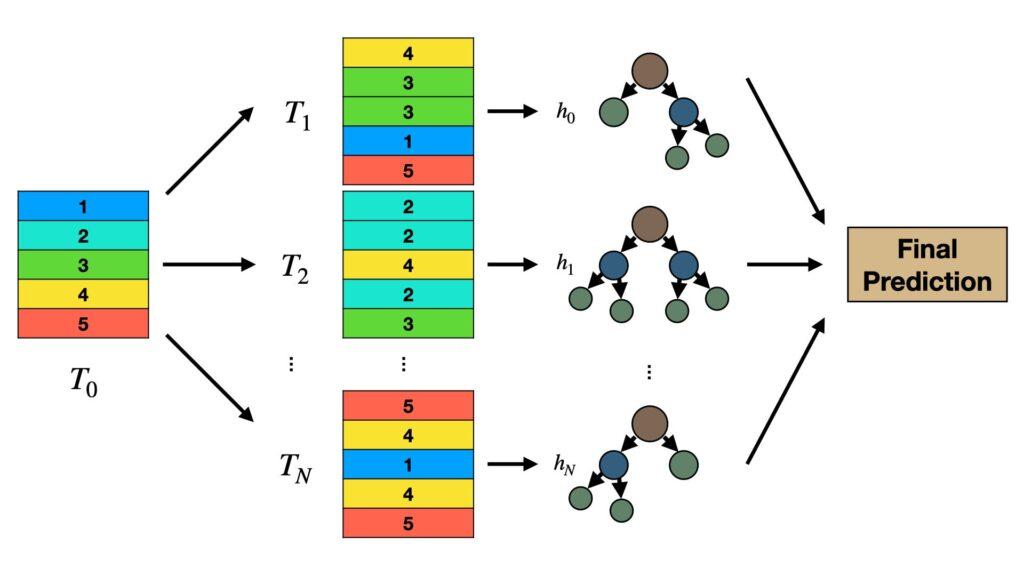

##3. Gradient Boosting (Boosting)

The **Gradient Boosting Regressor** is the most famous example of a Boosting ensemble method.

**Boosting **is an iterative technique that sequentially adjusts models to focus on the mistakes of previous models.

**How it Works**:

**Sequential Training**: It trains Decision Trees sequentially (one after the other).

**Focus on Errors**: Each new tree is trained to correct the errors (or residuals) made by the previous ensemble of trees. It works by moving in the direction of the steepest descent of the loss function (the "gradient").

**Weighted Voting**: The final prediction is a weighted sum of the predictions from all trees, where the contribution of each new tree is shrunk by a small learning rate.

**Goal**: Boosting primarily aims to reduce bias by turning many weak learners (each tree is simple, often with a low max_depth) into a single strong learner.

Here is a visual overview of the boosting process.

Source: https://towardsdatascience.com/10-decision-trees-are-better-than-1-719406680564/

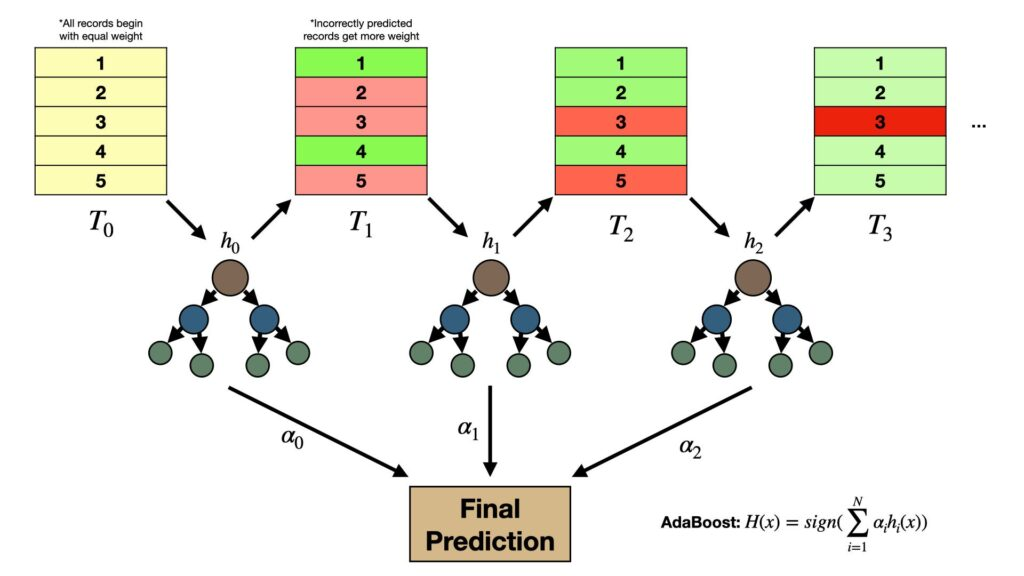

##Implementing and Comparing Ensemble Learning Models

We will implement each of these types of models to predict housing values using the California Housing dataset contained in `Scikit-learn`.

First, we load the necessary libraries.

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Data, Models, and Utilities
from sklearn.datasets import fetch_california_housing # Using California Housing (Boston is deprecated)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set a style for plots
sns.set_style("whitegrid")

Next, we load the dataset, set up the design matrix and response vector, and create a train/test split.  Note that we do not have to scale or standardize data when using these methods.

In [ ]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset features: {list(X.columns)}")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Training set size: 16512 samples
Testing set size: 4128 samples


##1. Decision Tree Regressor

We start with the simplest ensemble-based model, the Decision Tree. We initialize and train the regressor, then make predictions.

In [ ]:
# Initialize and train the Decision Tree Regressor
# Set max_depth to control complexity and prevent extreme overfitting
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_test)

**Model Metrics for Decision Tree**:
We calculate the Mean Squared Error (MSE) and the $R^2$ score.

In [ ]:
# Calculate metrics
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("--- Decision Tree Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {dt_mse:.3f}")
print(f"R-squared (R2) Score: {dt_r2:.3f}")

# Store results for comparison
dt_results = {'MSE': dt_mse, 'R2': dt_r2, 'Model': 'Decision Tree'}

--- Decision Tree Regressor Metrics ---
Mean Squared Error (MSE): 0.422
R-squared (R2) Score: 0.678


##Visualizing the Decision Tree Structure
We will use sklearn.tree.plot_tree to visualize the tree structure. Since the model has a maximum depth of 8, we will limit the visualized depth to 3 for a readable diagram.

--- Decision Tree Structure Visualization ---


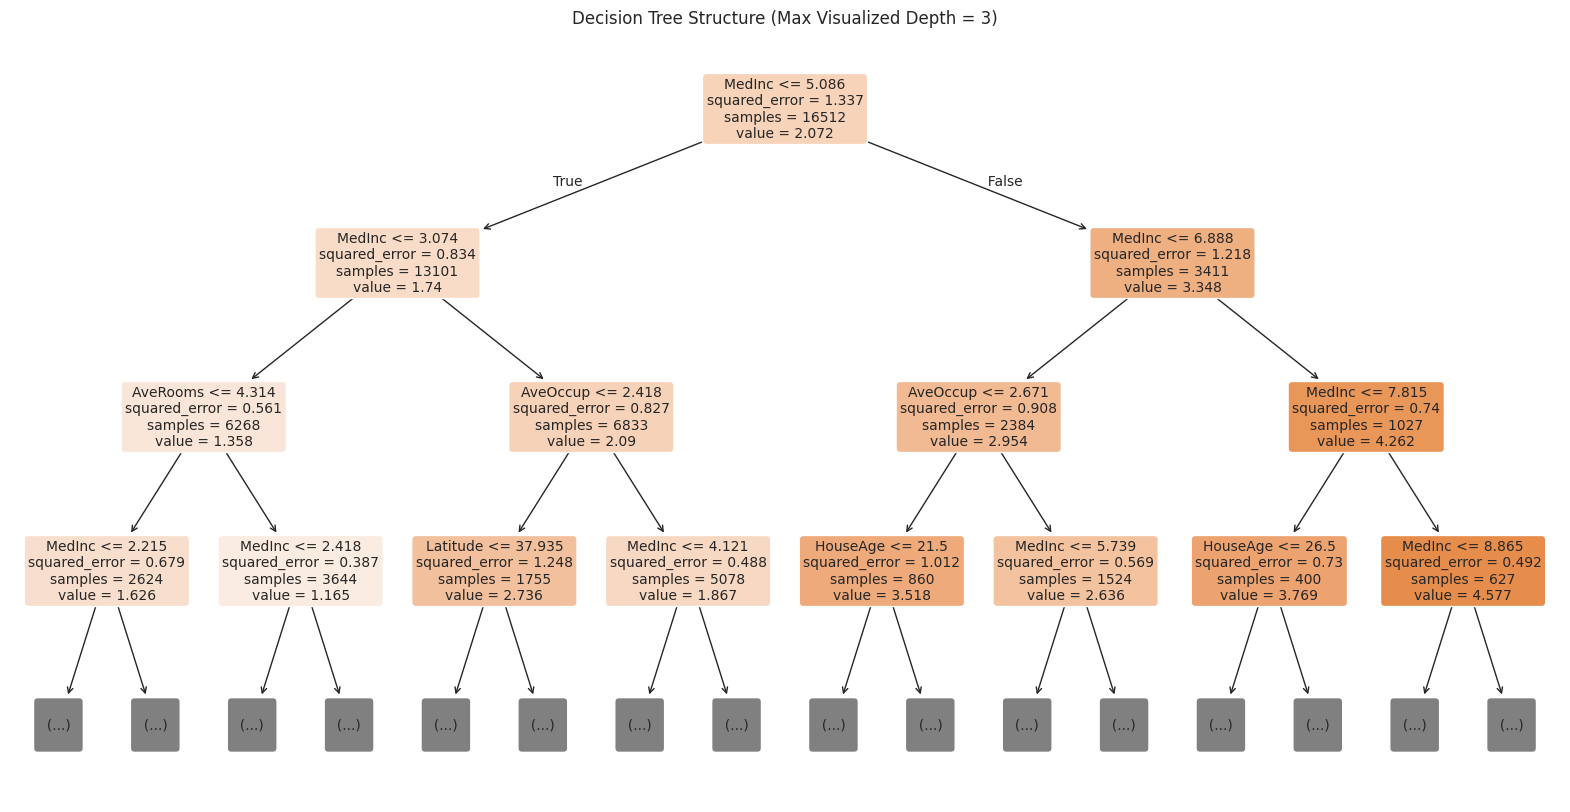

In [ ]:
from sklearn.tree import plot_tree

print("--- Decision Tree Structure Visualization ---")

# Set the maximum depth to visualize for readability
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,  # Limit depth for a clearer image
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree Structure (Max Visualized Depth = 3)")
plt.show()

**Interpretation:**

**Nodes:** Each box represents a decision node or a leaf node.

**Split Condition:** The top line shows the feature and threshold used to split the data (e.g., MedInc <= 5.035).

**mse:** The Mean Squared Error for the samples in that node. It decreases as you move down the tree, indicating purer nodes.

**samples:** The number of training samples in that node.

**value:** The average target value (median house value) for the samples in that node. This is the prediction made if this were a leaf node.

##Visualization of Predictions with Actual Values: Decision Tree

The scatter plot shows how closely the predictions align with the actual house price targets.

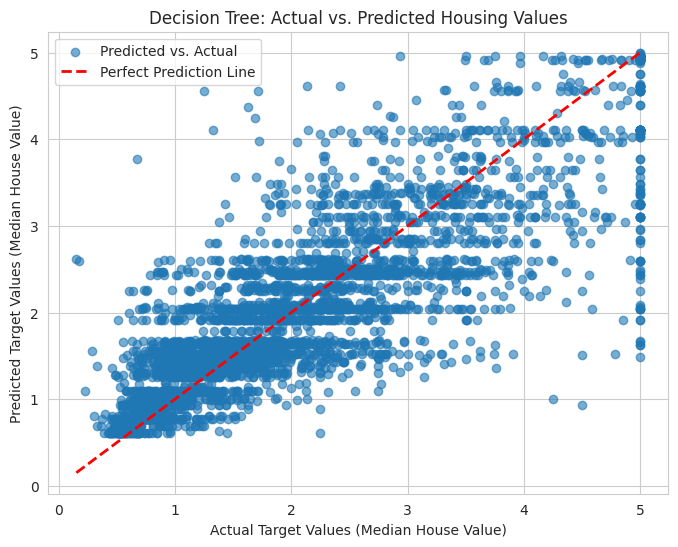

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_predictions, alpha=0.6, label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Decision Tree: Actual vs. Predicted Housing Values')
plt.xlabel('Actual Target Values (Median House Value)')
plt.ylabel('Predicted Target Values (Median House Value)')
plt.legend()
plt.show()

##2. Random Forest Regressor

The Random Forest aggregates predictions from many decision trees to reduce variance and improve generalization.

In [ ]:
# Initialize and train the Random Forest Regressor
# n_estimators is the number of trees in the forest
rf_model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

##Model Metrics for Random Forest Regressor

In [ ]:
# Calculate metrics
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("--- Random Forest Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {rf_mse:.3f}")
print(f"R-squared (R2) Score: {rf_r2:.3f}")

# Store results for comparison
rf_results = {'MSE': rf_mse, 'R2': rf_r2, 'Model': 'Random Forest'}

--- Random Forest Regressor Metrics ---
Mean Squared Error (MSE): 0.295
R-squared (R2) Score: 0.775


##Visualizing Random Forest Individual Tree Predictions

A Random Forest averages the output of many trees. Visualizing the distribution of predictions from each individual tree in the forest shows how much variation (or agreement) exists among the base learners

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

--- Random Forest Prediction Distribution ---
Sample True Value (y_test): 1.232
Random Forest Aggregate Prediction: 1.121
Prediction Standard Deviation: 0.131


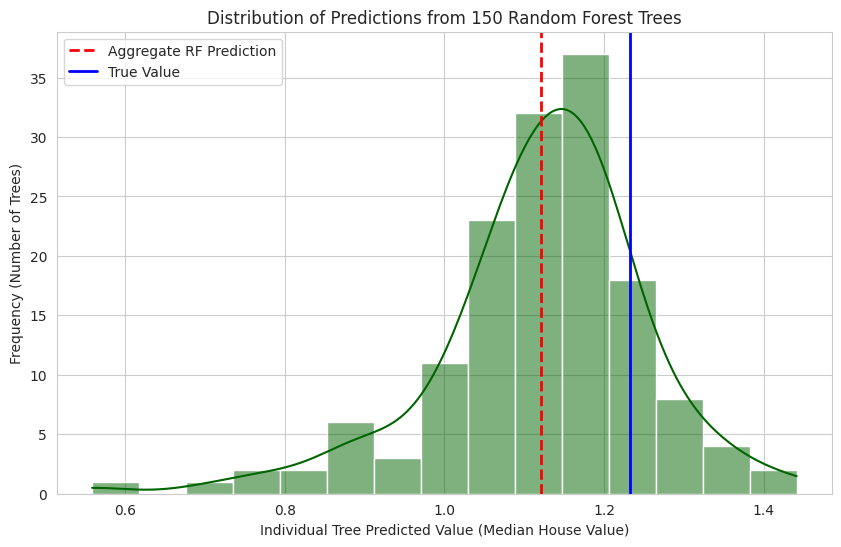

In [ ]:
# Select a single test sample to observe
test_sample_index = 10
sample_features = X_test.iloc[test_sample_index]
sample_true_value = y_test.iloc[test_sample_index]

# Get predictions from every individual tree in the Random Forest
tree_predictions = []
for tree in rf_model.estimators_:
    # Reshape the single sample to match the model's expected input (1, n_features)
    prediction = tree.predict(sample_features.to_frame().T)
    tree_predictions.append(prediction[0])

# Convert to Series for easy calculation
tree_predictions_series = pd.Series(tree_predictions)

print("--- Random Forest Prediction Distribution ---")
print(f"Sample True Value (y_test): {sample_true_value:.3f}")
print(f"Random Forest Aggregate Prediction: {rf_predictions[test_sample_index]:.3f}")
print(f"Prediction Standard Deviation: {tree_predictions_series.std():.3f}")


# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(tree_predictions_series, kde=True, bins=15, color='darkgreen')
plt.axvline(rf_predictions[test_sample_index], color='red', linestyle='--', linewidth=2, label='Aggregate RF Prediction')
plt.axvline(sample_true_value, color='blue', linestyle='-', linewidth=2, label='True Value')
plt.title(f'Distribution of Predictions from {len(rf_model.estimators_)} Random Forest Trees')
plt.xlabel('Individual Tree Predicted Value (Median House Value)')
plt.ylabel('Frequency (Number of Trees)')
plt.legend()
plt.show()

***Interpretation:***

**Distribution**: This histogram shows how frequently different values were predicted by the 150 individual trees in the Random Forest for a single data point.

**Red Dashed Line:** This is the final, reported prediction by the Random Forest model—the average of the entire distribution.

**Blue Solid Line:** This is the actual true value from the test set.

**Robustness**: A tight distribution (low standard deviation) indicates high agreement among the trees, suggesting a more robust prediction. The closer the red line is to the blue line, the more accurate the prediction is for this specific sample.

##Visualize Actual versus Predicted Values: Random Forest

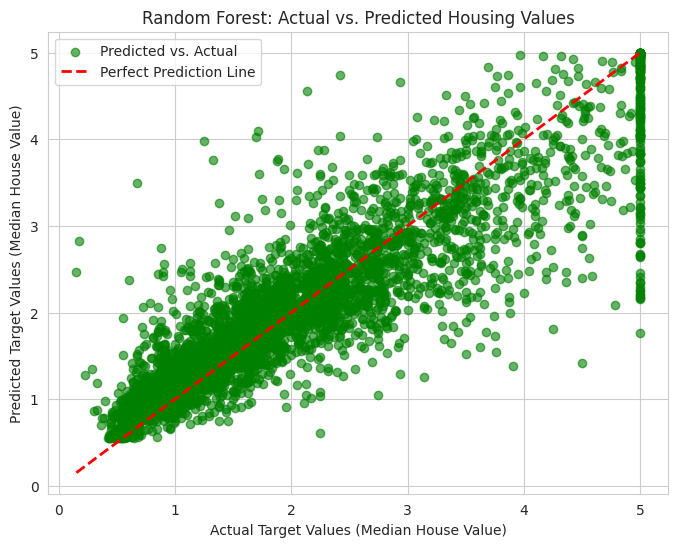

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.6, color='green', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Random Forest: Actual vs. Predicted Housing Values')
plt.xlabel('Actual Target Values (Median House Value)')
plt.ylabel('Predicted Target Values (Median House Value)')
plt.legend()
plt.show()

##3. Gradient Boosting Regressor
Gradient Boosting sequentially builds trees, where each new tree focuses on correcting the residuals (errors) of the preceding ensemble.

**Train the Gradient Boosting Regressor** and make predictions

In [ ]:
# Initialize and train the Gradient Boosting Regressor
# learning_rate controls the contribution of each tree
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
gb_predictions = gb_model.predict(X_test)

**Model Metrics for Gradient Boosting Regressor**

In [ ]:
# Calculate metrics
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("--- Gradient Boosting Regressor Metrics ---")
print(f"Mean Squared Error (MSE): {gb_mse:.3f}")
print(f"R-squared (R2) Score: {gb_r2:.3f}")

# Store results for comparison
gb_results = {'MSE': gb_mse, 'R2': gb_r2, 'Model': 'Gradient Boosting'}

--- Gradient Boosting Regressor Metrics ---
Mean Squared Error (MSE): 0.259
R-squared (R2) Score: 0.802


**Visualization of Actual Versus Predicted Values with Gradient Boosting**

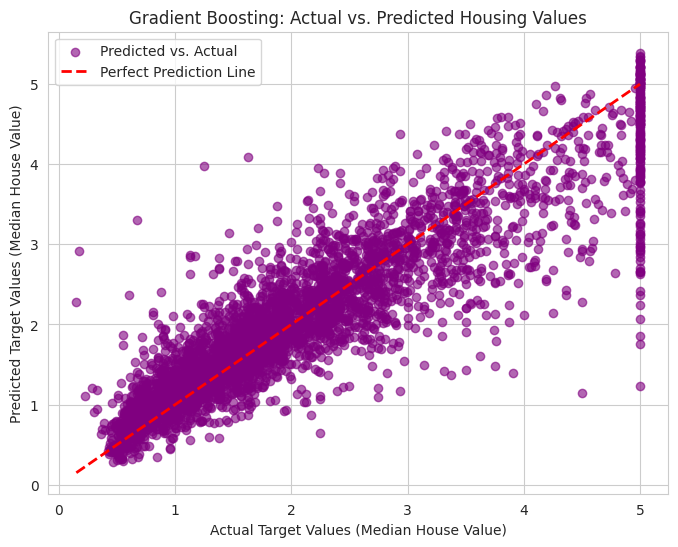

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, gb_predictions, alpha=0.6, color='purple', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Gradient Boosting: Actual vs. Predicted Housing Values')
plt.xlabel('Actual Target Values (Median House Value)')
plt.ylabel('Predicted Target Values (Median House Value)')
plt.legend()
plt.show()

**Feature Importance Analysis for Gradient Boosting**

The feature importance score is calculated by determining how much each feature reduces the impurity (or error, in the case of regression) across all splits in the trees of the ensemble.


1. Calculate and Display Feature Importance
We can access the feature importances directly from the trained gb_model object.

In [ ]:
# Access the feature importances from the trained Gradient Boosting model
importances = gb_model.feature_importances_

# Get the feature names
feature_names = X_train.columns

# Create a Series for easy sorting and plotting
feature_importance_series = pd.Series(importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importances = feature_importance_series.sort_values(ascending=False)

print("--- Gradient Boosting Feature Importance Scores ---")
print(sorted_importances.to_markdown(numalign="left", stralign="left", floatfmt=".4f"))

--- Gradient Boosting Feature Importance Scores ---
|            | 0      |
|:-----------|:-------|
| MedInc     | 0.5912 |
| AveOccup   | 0.1284 |
| Longitude  | 0.1069 |
| Latitude   | 0.0997 |
| HouseAge   | 0.0409 |
| AveRooms   | 0.0212 |
| AveBedrms  | 0.0068 |
| Population | 0.0049 |


2. Visualize Feature Importance

A bar chart provides the clearest way to compare the relative importance of all features.

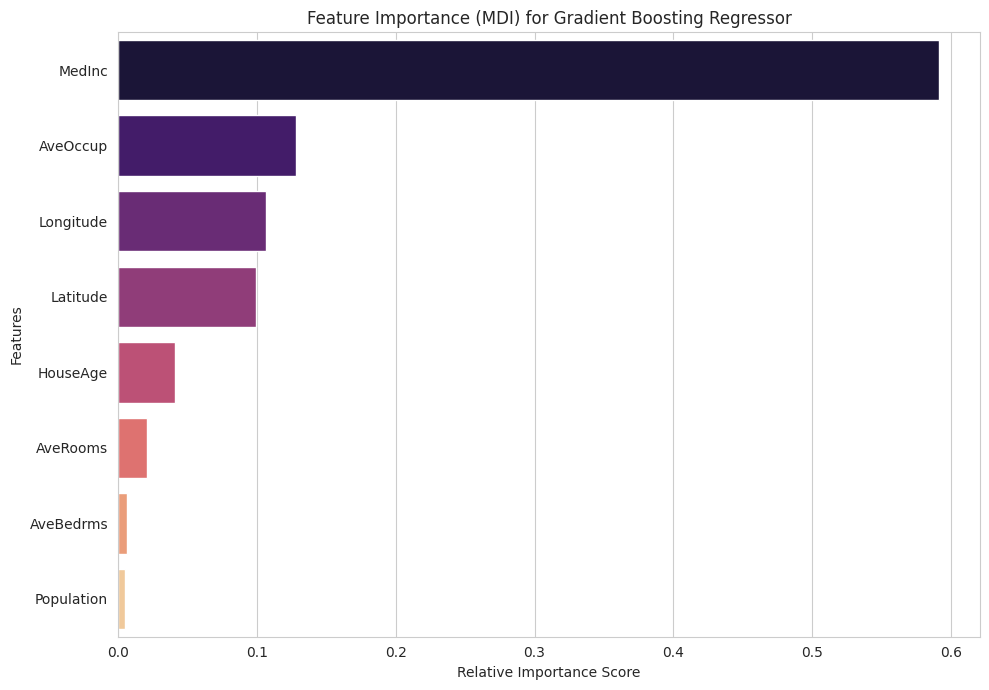

In [ ]:
### 2. Visualize Feature Importance (Corrected Code)

plt.figure(figsize=(10, 7))

# Create a bar plot using the sorted Series
# We assign the y variable (feature names) to hue to correctly map the palette.
sns.barplot(
    x=sorted_importances.values,
    y=sorted_importances.index,
    hue=sorted_importances.index,  # NEW: Assign the categorical y-variable to hue
    palette="magma",
    legend=False                   # NEW: Suppress the redundant legend
)

plt.title('Feature Importance (MDI) for Gradient Boosting Regressor')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

**Model Comparison**

We gather all metrics to determine the best model for this specific dataset.

In [ ]:
# Combine all results into a single DataFrame
comparison_df = pd.DataFrame([dt_results, rf_results, gb_results])

# Sort by R2 score (higher is better)
comparison_df = comparison_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n--- Final Model Comparison Table ---")
print(comparison_df.to_markdown(index=False))


--- Final Model Comparison Table ---
|      MSE |       R2 | Model             |
|---------:|---------:|:------------------|
| 0.259494 | 0.801975 | Gradient Boosting |
| 0.295304 | 0.774647 | Random Forest     |
| 0.422045 | 0.677928 | Decision Tree     |


Visualize Comparison

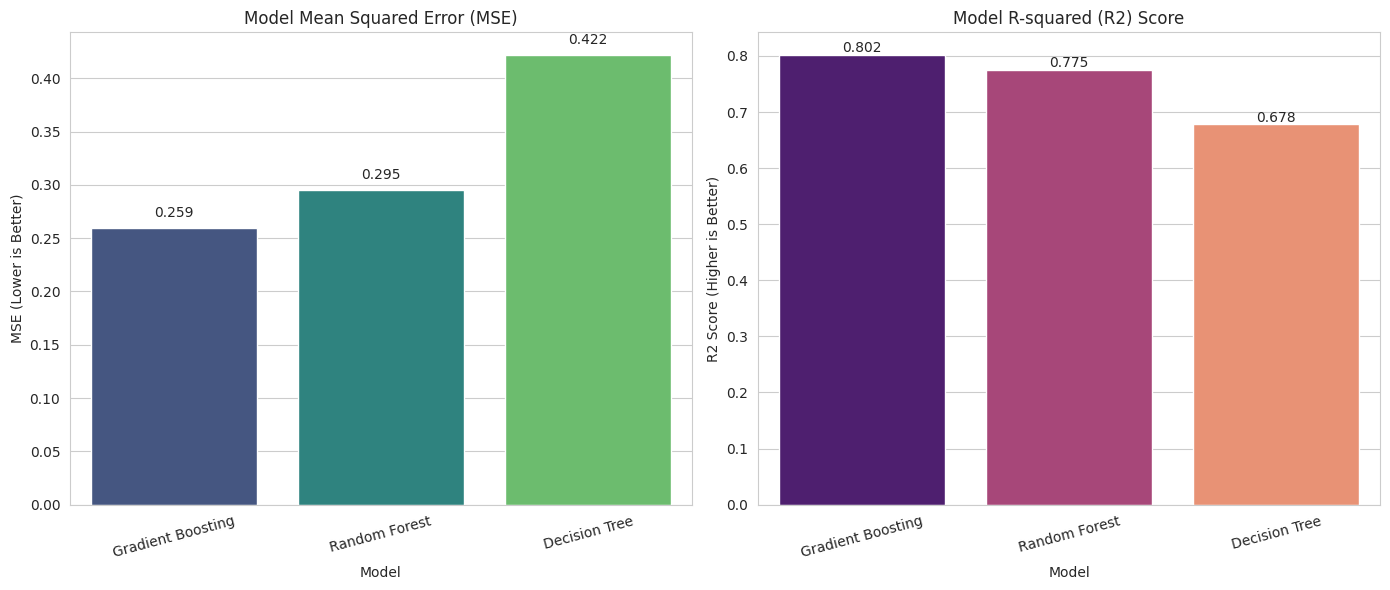

In [ ]:
### 5.2 Visualize Comparison (Corrected Code)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = comparison_df['Model']
mse_scores = comparison_df['MSE']
r2_scores = comparison_df['R2']

# --- Corrected MSE Comparison Plot ---
# Assign 'models' to hue to correctly map palette colors to categories
sns.barplot(
    ax=axes[0],
    x=models,
    y=mse_scores,
    hue=models,             # NEW: Assign models to hue
    palette="viridis",
    legend=False            # NEW: Suppress the redundant legend
)
axes[0].set_title('Model Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE (Lower is Better)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(mse_scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')

# --- Corrected R2 Comparison Plot ---
# Assign 'models' to hue to correctly map palette colors to categories
sns.barplot(
    ax=axes[1],
    x=models,
    y=r2_scores,
    hue=models,             # NEW: Assign models to hue
    palette="magma",
    legend=False            # NEW: Suppress the redundant legend
)
axes[1].set_title('Model R-squared (R2) Score')
axes[1].set_ylabel('R2 Score (Higher is Better)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

##4.  Support Vector Machines

As we've seen previously, SVMs belong to a fundamentally different family of algorithms.  However, they can be combined with ensemble techniques.

SVM find a single, optimal hyperplane to distinguish classes. Feature scaling is required, since the method depens on distance metrics.

To implement an SVM model, we load the following libraries, in addition to those previously loaded.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

Next, we specify a model pipeline with scaling, which is crucial for SVM.

In [ ]:
# We use a pipeline to scale the data first, then apply SVR.
# C: regularization parameter (higher C means less regularization, closer fit to training data)
# gamma: kernel coefficient for RBF (controls how far the influence of a single training example reaches)
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=10.0, gamma='scale'))
])

print("Training the SVR model (This may take a moment on a large dataset)...")

Training the SVR model (This may take a moment on a large dataset)...


Now we train the model, make predictions, and view model metrics.

In [ ]:
# 3. Model Training
svr_model.fit(X_train, y_train)

# 4. Prediction
svr_predictions = svr_model.predict(X_test)

# 5. Metrics
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_r2 = r2_score(y_test, svr_predictions)

print("\n--- Support Vector Regressor (SVR) Metrics ---")
print(f"Mean Squared Error (MSE): {svr_mse:.3f}")
print(f"R-squared (R2) Score: {svr_r2:.3f}")


--- Support Vector Regressor (SVR) Metrics ---
Mean Squared Error (MSE): 0.324
R-squared (R2) Score: 0.753


Now we view a plot of the actual versus predicted values.

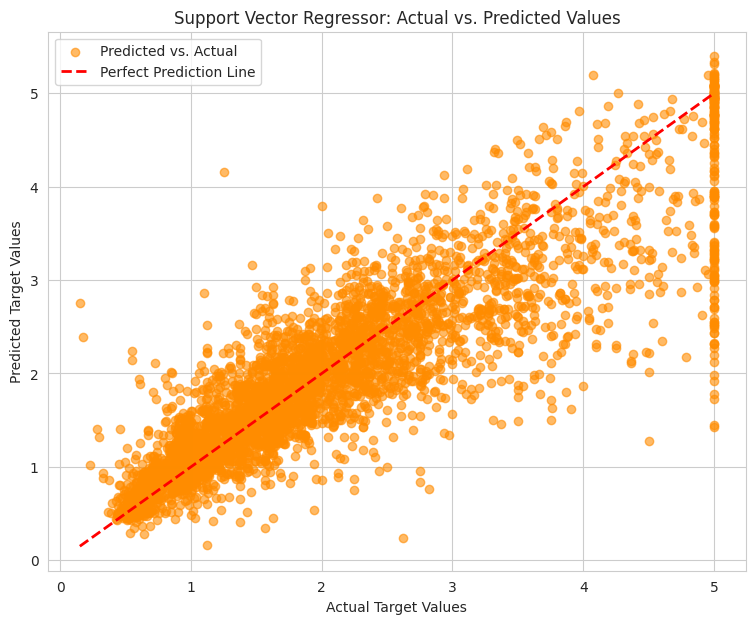

In [ ]:
plt.figure(figsize=(9, 7))
plt.scatter(y_test, svr_predictions, alpha=0.6, color='darkorange', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Support Vector Regressor: Actual vs. Predicted Values')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend()
# Note: plt.show() is used for explicit clarity but is not strictly necessary
# in this environment if no plt.close() or plt.savefig() is called.
plt.show()

Here is a complete pipeline for implementing an SVR with bagging.


Training the Bagged SVR model (This will take significantly longer)...

--- Bagged Support Vector Regressor (SVR) Metrics ---
Mean Squared Error (MSE): 0.325
R-squared (R2) Score: 0.752


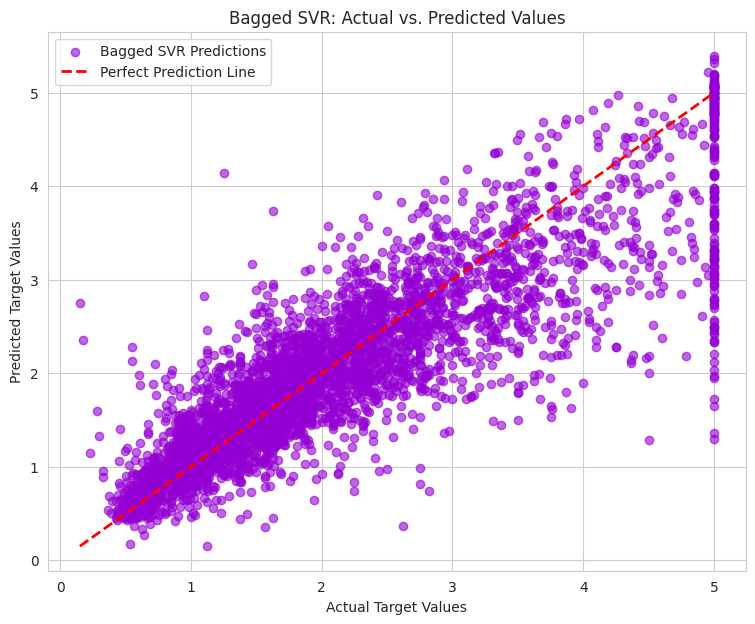

In [ ]:
from sklearn.ensemble import BaggingRegressor

# --- 1. Define the Base Estimator ---
base_svr = SVR(kernel='rbf', C=10.0, gamma='scale')

# --- 2. Define the Bagging Regressor ---
# n_estimators=10: Use 10 SVR models
bagged_svr = BaggingRegressor(
    estimator=base_svr,
    n_estimators=10,
    max_samples=1.0,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# --- 3. Create the Final Pipeline (Scaling + Bagging) ---
bagging_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('bagged_svr', bagged_svr)
])

print("\nTraining the Bagged SVR model (This will take significantly longer)...")
# 4. Model Training
bagging_pipeline.fit(X_train, y_train)

# 5. Prediction
bagged_svr_predictions = bagging_pipeline.predict(X_test)

# 6. Metrics
bagged_svr_mse = mean_squared_error(y_test, bagged_svr_predictions)
bagged_svr_r2 = r2_score(y_test, bagged_svr_predictions)

print("\n--- Bagged Support Vector Regressor (SVR) Metrics ---")
print(f"Mean Squared Error (MSE): {bagged_svr_mse:.3f}")
print(f"R-squared (R2) Score: {bagged_svr_r2:.3f}")

# --- 7. Visualization and Comparison ---
plt.figure(figsize=(9, 7))
plt.scatter(y_test, bagged_svr_predictions, alpha=0.6, color='darkviolet', label='Bagged SVR Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Bagged SVR: Actual vs. Predicted Values')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend()
plt.show()

And here is code to implement the SVM with boosting, using the AdaBoost


Training the AdaBoost SVR model (This will take a significant time)...

--- AdaBoost Support Vector Regressor (SVR) Metrics ---
Mean Squared Error (MSE): 0.341
R-squared (R2) Score: 0.739


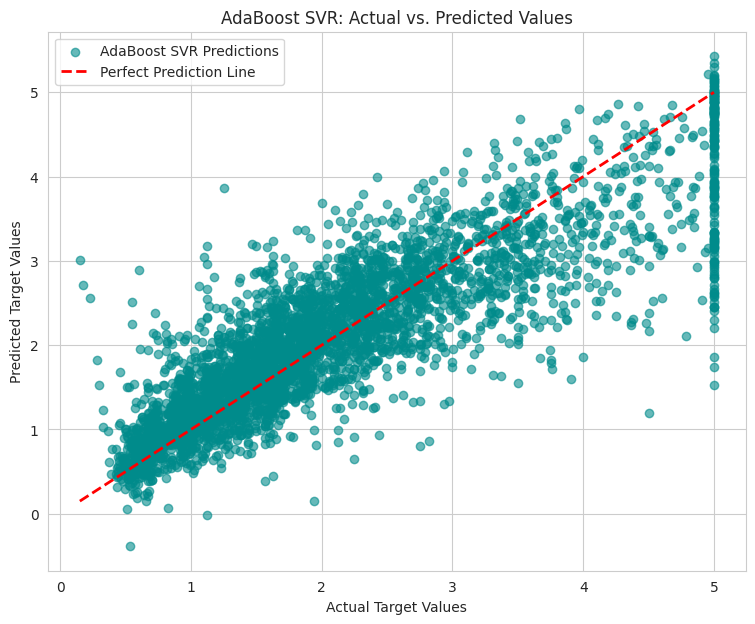

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

# --- 1. Define the Base Estimator ---
# Note: SVR can be sensitive to the C and epsilon parameters in AdaBoost.
base_svr = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)

# --- 2. Define the AdaBoost Regressor ---
# n_estimators=10: Use 10 SVR models sequentially
# learning_rate: Controls the contribution of each SVR
ada_svr = AdaBoostRegressor(
    estimator=base_svr,
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)

# --- 3. Create the Final Pipeline (Scaling + Boosting) ---
ada_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ada_svr', ada_svr)
])

print("\nTraining the AdaBoost SVR model (This will take a significant time)...")
# 4. Model Training
ada_pipeline.fit(X_train, y_train)

# 5. Prediction
ada_svr_predictions = ada_pipeline.predict(X_test)

# 6. Metrics
ada_svr_mse = mean_squared_error(y_test, ada_svr_predictions)
ada_svr_r2 = r2_score(y_test, ada_svr_predictions)

print("\n--- AdaBoost Support Vector Regressor (SVR) Metrics ---")
print(f"Mean Squared Error (MSE): {ada_svr_mse:.3f}")
print(f"R-squared (R2) Score: {ada_svr_r2:.3f}")

# --- 7. Visualization and Comparison ---
plt.figure(figsize=(9, 7))
plt.scatter(y_test, ada_svr_predictions, alpha=0.6, color='darkcyan', label='AdaBoost SVR Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('AdaBoost SVR: Actual vs. Predicted Values')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend()
plt.show()

We'll compare the results, based on the models trained above.

In [ ]:
# 1. Create a list of dictionaries with the results
comparison_results = [
    {'Model': 'Single SVR', 'MSE': svr_mse, 'R2': svr_r2},
    {'Model': 'Bagged SVR', 'MSE': bagged_svr_mse, 'R2': bagged_svr_r2},
    {'Model': 'AdaBoost SVR', 'MSE': ada_svr_mse, 'R2': ada_svr_r2}
]

# 2. Convert to DataFrame and sort by R2 (highest is best)
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n--- Consolidated SVR Model Comparison Table ---")
# Display the table formatted nicely
print(comparison_df.to_markdown(index=False, floatfmt=".4f"))


--- Consolidated SVR Model Comparison Table ---
| Model        |    MSE |     R2 |
|:-------------|-------:|-------:|
| Single SVR   | 0.3237 | 0.7530 |
| Bagged SVR   | 0.3249 | 0.7520 |
| AdaBoost SVR | 0.3415 | 0.7394 |


Generate Comparison Plots

This code generates the two plots side-by-side to visually compare the MSE (lower is better) and $R^2$ (higher is better).

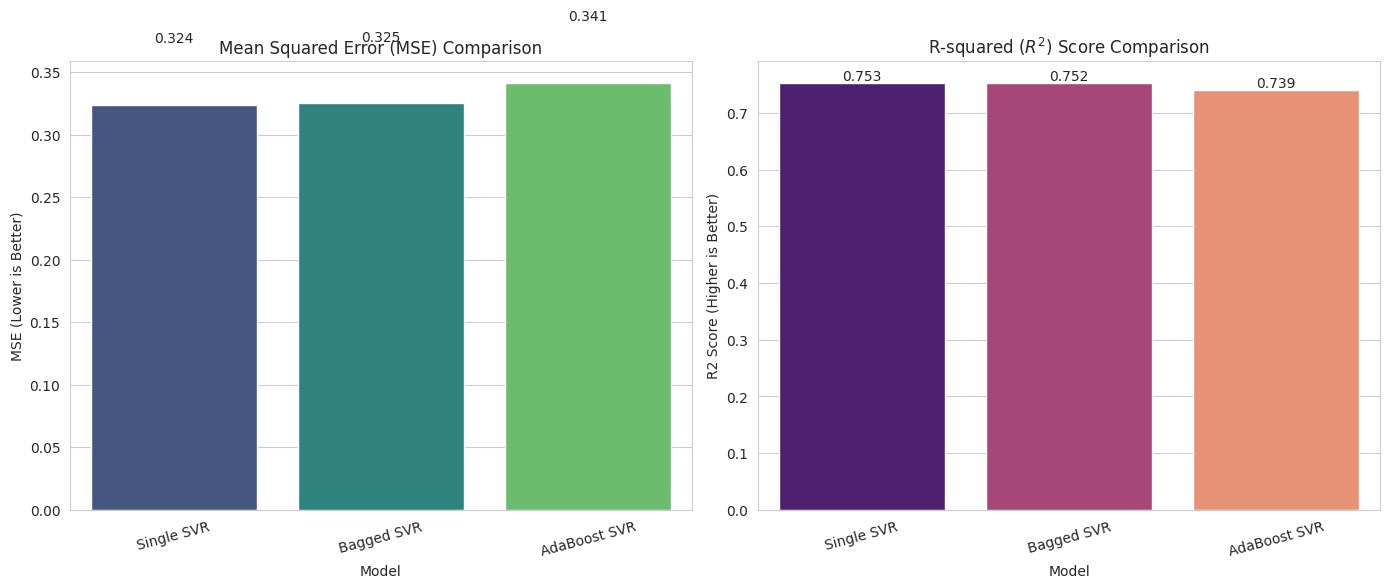

In [ ]:
# Extract data for plotting
models = comparison_df['Model']
mse_scores = comparison_df['MSE']
r2_scores = comparison_df['R2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: MSE Comparison (Lower is Better) ---
sns.barplot(ax=axes[0], x=models, y=mse_scores, hue=models, palette="viridis", legend=False)
axes[0].set_title('Mean Squared Error (MSE) Comparison')
axes[0].set_ylabel('MSE (Lower is Better)')
axes[0].tick_params(axis='x', rotation=15)
# Add metric values on top of bars
for i, v in enumerate(mse_scores):
    axes[0].text(i, v + 0.05, f"{v:.3f}", ha='center')

# --- Plot 2: R2 Comparison (Higher is Better) ---
sns.barplot(ax=axes[1], x=models, y=r2_scores, hue=models, palette="magma", legend=False)
axes[1].set_title('R-squared ($R^2$) Score Comparison')
axes[1].set_ylabel('R2 Score (Higher is Better)')
axes[1].tick_params(axis='x', rotation=15)
# Add metric values on top of bars
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()